<a href="https://colab.research.google.com/github/annhater/M1_STAGE/blob/main/2_notebooks/02_analysis_interactions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install MDAnalysis
!pip install MDAnalysisTests

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 MB 12.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.6/529.6 kB 33.2 MB/s eta 0:00:00
  Created wheel for MDAnalysisTests: filename=mdanalysistests-2.10.0-py3-none-any.whl size=58343066 sha256=14c5a2ea3f5abef00af5df095183406dade98a49117c98e558f148d6c4e228ad
  Stored in directory: /root/.cache/pip/wheels/48/cc/44/560d1d4b77f1a4b0a8cb5be5d12001c911d7e6190511d7e571
Successfully built MDAnalysisTests


## HB interactions bw Aps25, in V12 sim


In [ ]:
#IMPORTS
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import math

#SETUP
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/interactions/'
os.chdir(rootdir)

#FUNCTIONS

# a. Open interactions file
def find_asp_int(interactions_file):
    interactions_df = pd.read_csv(interactions_file)
    #ASP_25_cols = [col for col in interactions_df.columns if 'ASP_25' in col]
    #print(list(interactions_df.columns))
    HB_ASP_25_cols = [col for col in interactions_df.columns if 'ASP_25' in col and 'hb' in col]
    for present_interactions in HB_ASP_25_cols:
        if interactions_df[present_interactions].sum() > 0:
            print(present_interactions)
#MAIN

# 1. fetch all interaction files
#store all file paths
simulations_list = ['res_V1.csv', 'res_V11.csv', 'res_V12.csv', 'res_V21.csv', 'res_V7.csv', 'res_V8.csv']
interactions_files_paths = []

for root, dirs, files in os.walk(rootdir):
   for name in files:
      if name in simulations_list:
        interactions_files_paths.append(os.path.join(rootdir, name))

for i, interactions_file in enumerate(interactions_files_paths):
    # get simulation name from filename
    simulation_name = os.path.basename(os.path.normpath(interactions_file)).replace("res_", "").replace(".csv", "")
    print(f"Simulation: {simulation_name}")

    find_asp_int(interactions_file)


Simulation: V7
hbsb_ASP_25_OD1_GLY_126_N
hbsb_ASP_25_OD2_GLY_126_N
hbsb_ALA_28_N_ASP_25_OD2
hbss_ASP_124_OD2_ASP_25_OD2
hbsb_ASP_25_OD1_THR_26_N
hbss_ASP_124_OD2_ASP_25_OD1
hbsb_ALA_28_N_ASP_25_OD1
hbbb_ASP_25_O_GLY_27_N
hbsb_ALA_127_N_ASP_25_OD2
hbsb_ALA_127_N_ASP_25_OD1
hbsb_ASP_25_N_THR_125_OG1
hbsb_ASP_25_OD2_THR_125_N
hbsb_ASP_25_OD2_GLY_27_N
hbbb_ALA_28_N_ASP_25_O
hbbb_ASP_25_N_PHE_85_O
hbbb_ASP_25_N_LEU_23_O
hbsb_ASP_25_OD2_THR_26_N
hbsb_ASP_25_OD1_THR_125_N
hbbb_ARG_87_N_ASP_25_O
hbsb_ASP_25_OD1_GLY_27_N
Simulation: V8
hbsb_ASP_25_OD1_GLY_126_N
hbsb_ASP_25_OD2_GLY_126_N
hbsb_ALA_28_N_ASP_25_OD2
hbss_ASP_124_OD2_ASP_25_OD2
hbsb_ASP_25_OD1_THR_26_N
hbss_ASP_124_OD2_ASP_25_OD1
hbsb_ALA_28_N_ASP_25_OD1
hbbb_ASP_25_O_GLY_27_N
hbsb_ALA_127_N_ASP_25_OD2
hbsb_ALA_127_N_ASP_25_OD1
hbsb_ASP_25_N_THR_125_OG1
hbsb_ASP_25_OD2_THR_125_N
hbsb_ASP_25_OD2_GLY_27_N
hbbb_ALA_28_N_ASP_25_O
hbbb_ASP_25_N_PHE_85_O
hbbb_ASP_25_N_LEU_23_O
hbsb_ASP_25_OD2_THR_26_N
hbsb_ASP_25_OD1_THR_125_N
hbbb_ARG_87_

In [ ]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
import math

V12_df = pd.read_csv('/content/drive/MyDrive/M1_STAGE/Data/interactions/res_V12.csv')
ASP_25_cols = [col for col in V12_df.columns if 'hb' in col and 'ASP_124' in col]
for present_interactions in ASP_25_cols:
    if V12_df[present_interactions].sum() > 0:
        filtered_df = V12_df.loc[V12_df[present_interactions]>0]

filtered_df

#V12_df.loc[V12_df['hbsb_ASP_25_OD2_THR_125_N'] > 0]['hbsb_ASP_25_OD2_THR_125_N']

,vdw_ALA_172_C_VAL_161_O,vdw_GLY_49_CA_MET_76_CE,vdw_GLY_52_O_ILE_149_N,vdw_ILE_114_CA_ILE_163_CD,vdw_GLY_185_C_LEU_189_CD1,vdw_ARG_186_CB_THR_190_CG2,vdw_ILE_181_CB_THR_179_CG2,vdw_GLY_17_C_TYR_14_CA,vdw_ILE_32_CG2_ILE_82_CB,vdw_ARG_186_CB_TRP_6_NE1,...,hbsb_ALA_133_N_ASN_182_OD1,vdw_ALA_127_C_ARG_186_CG,hbsb_PRO_1_O_SER_4_OG,vdw_ILE_149_O_PRO_180_CB,vdw_GLN_117_CD_GLY_134_O,vdw_LEU_5_CB_PHE_3_CD1,vdw_GLU_162_CD_GLU_164_OE1,vdw_GLY_51_C_PHE_152_C,vdw_ASN_98_CG_PRO_1_O,hbsb_GLN_2_NE2_SER_4_N
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


/tmp/ipykernel_3363/2721170386.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3363/2721170386.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3363/2721170386.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3363/2721170386.py:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()
/tmp/ipykernel_3363/2721170386.py:52: UserWarning: No artists with labels found to put in legend.  Note that art

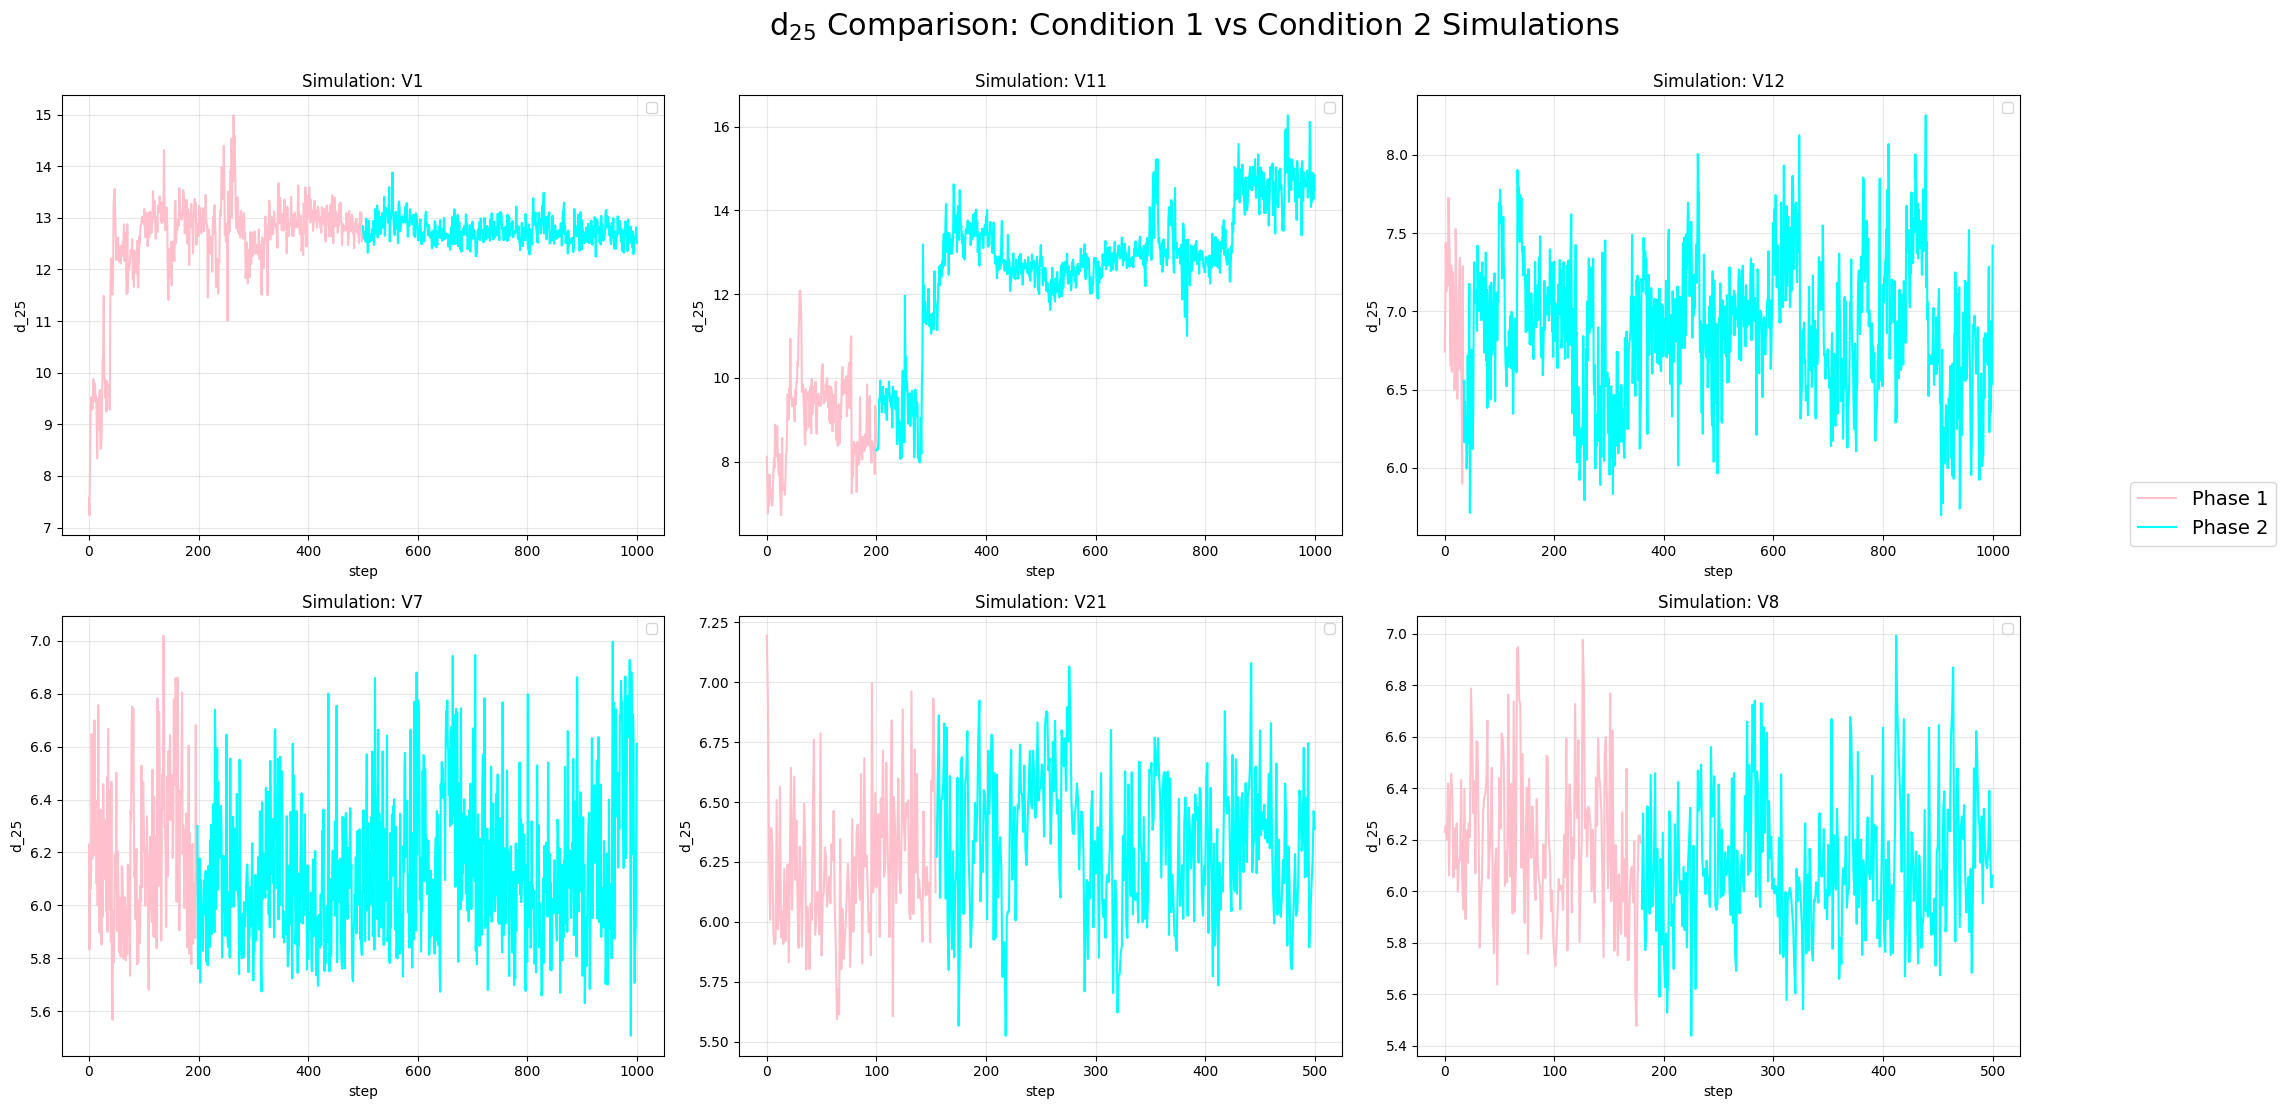

In [ ]:
# # Determine grid size for subplots
# num_files = len(interactions_files_paths)
# # Adjust ncols and nrows to create a somewhat square grid
# num_cols = min(num_files, 3)
# num_rows = math.ceil(num_files / num_cols)

# phase_limit_dico = {
#     'V7': 198,
#     'V8': 180,
#     'V21': 155,
#     'V12': 35,
#     'V11': 200,
#     'V1': 517,
# }

fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 8, num_rows * 6), squeeze=False)
axes = axes.flatten()
fig.suptitle("d$_{25}$ Comparison: Condition 1 vs Condition 2 Simulations", fontsize=22, y=0.92)
plot_idx = 0
line_c1 = None
line_c2 = None

# 2. iterate on each distance file
# 2.1 create pd DF for each distance file
for i, distance_file in enumerate(distance_files_paths):
    ax = axes[plot_idx]

    #transform into pd dataframe
    distance_df = pd.read_csv(distance_file)
    #transform GROMACS distances in nm to Angstrom (1 nm = 10 A)
    distance_df = distance_df * 10
    distance_df.index.names = ['step']

    # 2.2 compute d_25 for each distance file
    time_d_25 = cal_d_25(distance_df)
    time_d_25_df = pd.DataFrame(time_d_25)
    time_d_25_df.columns.values[0] = "d_25"

    #plot on the current subplot
    #to do: change the phase borders for each simulation accordingly
    simulation_name = os.path.basename(os.path.normpath(distance_file)).replace("distance_", "").replace(".csv", "")

    if simulation_name in phase_limit_dico:
        phase_limit = phase_limit_dico[simulation_name]
    line_c1, = ax.plot(time_d_25_df.index[:phase_limit], time_d_25_df['d_25'][:phase_limit], color='pink', linewidth=1.5)
    line_c2, = ax.plot(time_d_25_df.index[phase_limit:], time_d_25_df['d_25'][phase_limit:], color='cyan', linewidth=1.5)

    ax.set_title(f"Simulation: {simulation_name}")
    ax.set_xlabel('step')
    ax.set_ylabel('d_25')
    ax.grid(True, alpha=0.3) # Add a grid to the plot
    ax.legend()
    plot_idx += 1


# hide any unused subplots
for j in range(plot_idx + 1, len(axes)):
    fig.delaxes(axes[j])

# legend
fig.legend(handles=[line_c1, line_c2],     # The line objects
           labels=["Phase 1", "Phase 2"],   # The labels for each line
           loc="center",  # Position of legend
           bbox_to_anchor=(0.92, 0.5),    # Small spacing around legend box
           title_fontsize='18',
           fontsize='14',
           frameon=True
           )
plt.tight_layout(rect=[0, 0, 0.85, 0.92])
plt.show()
#save plot
fig.savefig("/content/drive/MyDrive/M1_STAGE/Manips/Figures/d_25_25.png", bbox_inches='tight', dpi=300)



In [ ]:
#calculate the statistics
summary_stats_dict = {} # dico to store loop results

for i, distance_file in enumerate(distance_files_paths):
    # get simulation name from filename
    simulation_name = os.path.basename(os.path.normpath(distance_file)).replace("distance_", "").replace(".csv", "")

    #transform into pd dataframe
    distance_df = pd.read_csv(distance_file)
    #transform GROMACS distances in nm to Angstrom (1 nm = 10 A)
    distance_df = distance_df * 10
    distance_df.index.names = ['step']

    # 2.2 compute d_50 for each distance file
    time_d_25 = cal_d_25(distance_df)
    time_d_25_df = pd.DataFrame(time_d_25)
    time_d_25_df.columns.values[0] = "d_25"
    # 2.3. store the result into stat dico
    summary_stats_dict[simulation_name] = time_d_25_df['d_25'].describe()

summary_stats_df = pd.DataFrame(summary_stats_dict)


# write csv
summary_stats_df.to_csv('/content/drive/MyDrive/M1_STAGE/Manips/d_25_stats.csv', index=True, header=True, decimal=".", float_format="%.3f")


In [ ]:
summary_stats_df

,V1,V11,V12,V7,V21,V8
count,1001.000000,1001.000000,1001.000000,1001.000000,501.000000,501.000000
mean,20.579889,17.436174,15.230471,14.544357,14.489182,14.865898
std,3.087334,3.750270,1.235756,1.200957,1.889353,1.907410
min,10.190392,9.354447,11.454055,11.205486,10.519024,11.361641
25%,19.175210,14.584466,14.378376,13.793901,13.481281,13.721450
50%,21.564600,17.476760,15.163096,14.446552,14.411055,14.507950
75%,22.518227,20.156238,15.990262,15.071913,15.433499,15.265822
max,29.043345,28.605335,20.755842,23.450718,24.141748,23.015838


In [ ]:
#check length of V8
import pandas as pd
import os
rootdir = '/content/drive/MyDrive/M1_STAGE/Data/simulations_1HSI/simulations_1HSI_APO_MP/V8/'
os.chdir(rootdir)
df = pd.read_csv("distance_V8.csv")
df.tail()

,1_4,1_5,1_6,1_7,1_8,1_9,1_10,1_11,1_12,1_13,...,192_198,193_196,193_197,193_198,194_197,194_198,195_198,99_101,100_101,100_102
496,0.940495,1.186516,1.389970,1.509195,1.540226,1.582051,1.680861,1.515835,1.744366,1.899360,...,1.924236,1.054098,1.242503,1.624544,0.965463,1.351729,1.057205,0.643551,0.396904,0.735701
497,0.961977,1.224481,1.440317,1.550736,1.652161,1.560040,1.664393,1.471117,1.715183,1.735628,...,1.857832,1.058890,1.213612,1.579039,0.903692,1.281477,1.009258,0.658411,0.385418,0.691910
498,0.971293,1.232813,1.405496,1.586882,1.539090,1.630275,1.580100,1.348853,1.515427,1.513065,...,1.862673,1.076647,1.243840,1.613172,0.914816,1.289597,1.011538,0.597965,0.379907,0.688068
499,0.917706,1.181514,1.412735,1.493310,1.495899,1.510911,1.476843,1.268550,1.487693,1.620323,...,1.866217,1.061567,1.218269,1.589054,0.925091,1.305946,0.990795,0.634031,0.386432,0.714822
500,0.962645,1.204357,1.428906,1.529719,1.443520,1.489729,1.430945,1.200475,1.390940,1.523544,...,1.926659,1.057813,1.258429,1.644437,0.959513,1.347852,1.027820,0.630277,0.388567,0.662454
